In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# from loss_dinn_LLM import loss_dinn


def loss_dinn(S_hat, S_pred, I_hat, I_pred, D_hat, D_pred, R_hat, R_pred, f1, f2, f3, f4, I_pred_last, train_size):
    S_pred_slice = S_pred[:train_size]
    I_pred_slice = I_pred[:train_size]
    R_pred_slice = R_pred[:train_size]
    D_pred_slice = D_pred[:train_size]

    regul = 0.9
    last_infected_penalty = 0.1

    aggregation_func = torch.mean
    norm_func = torch.square

    peak_index = torch.argmax(I_pred_slice)
    term1 = aggregation_func(norm_func(S_hat - S_pred_slice))
    epidemic_peak_penalty = torch.mean(torch.where(I_pred_slice >= I_pred_slice[peak_index] - torch.std(I_pred_slice[peak_index - 3:peak_index + 3]) * 2,
                                                  norm_func(I_pred_slice - I_pred_slice[peak_index]), torch.tensor(0., dtype=torch.float64)))

    term2 = aggregation_func(norm_func(I_hat - I_pred_slice))
    term3 = aggregation_func(norm_func(D_hat - D_pred_slice))
    term4 = aggregation_func(norm_func(R_hat - R_pred_slice))

    term5 = aggregation_func(norm_func(f1))
    term6 = aggregation_func(norm_func(f2))
    term7 = aggregation_func(norm_func(f3))
    term8 = aggregation_func(norm_func(f4))

    loss = regul * (term1 + 0.2 * term2 + term3 + term4) + \
            (1 - regul) * (term5 + term6 + term7 + term8) + \
            last_infected_penalty * torch.mean(norm_func(I_pred_last - 0)) + \
            0.6 * aggregation_func(norm_func(epidemic_peak_penalty))

    return loss




class DINN(nn.Module):
    def __init__(self, t, S_data, I_data, D_data, R_data, device, train_size):
        super(DINN, self).__init__()
        self.device = device
        self.N = 6e6
        self.t = torch.tensor(t, requires_grad=True, device=self.device)
        self.t_float = self.t.float()
        self.t_batch = torch.reshape(self.t_float, (len(self.t), 1))
        self.S = torch.tensor(S_data, device=self.device)
        self.I = torch.tensor(I_data, device=self.device)
        self.D = torch.tensor(D_data, device=self.device)
        self.R = torch.tensor(R_data, device=self.device)
        self.train_size = train_size

        self.losses = []

        self.beta_tilda = torch.nn.Parameter(torch.rand(1, requires_grad=True, device=self.device))
        self.gamma_tilda = torch.nn.Parameter(
            torch.rand(1, requires_grad=True, device=self.device))

        # Нормализация только по обучающей части (первые train_size точек)
        self.S_max = max(self.S[:train_size])
        self.I_max = max(self.I[:train_size])
        self.D_max = max(self.D[:train_size])
        self.R_max = max(self.R[:train_size])
        self.S_min = min(self.S[:train_size])
        self.I_min = min(self.I[:train_size])
        self.D_min = min(self.D[:train_size])
        self.R_min = min(self.R[:train_size])

        self.S_hat = (self.S - self.S_min) / (self.S_max - self.S_min)
        self.I_hat = (self.I - self.I_min) / (self.I_max - self.I_min)
        self.D_hat = (self.D - self.D_min) / (self.D_max - self.D_min)
        self.R_hat = (self.R - self.R_min) / (self.R_max - self.R_min)

        self.m1 = torch.zeros((len(self.t), 4), device=self.device)
        self.m1[:, 0] = 1
        self.m2 = torch.zeros((len(self.t), 4), device=self.device)
        self.m2[:, 1] = 1
        self.m3 = torch.zeros((len(self.t), 4), device=self.device)
        self.m3[:, 2] = 1
        self.m4 = torch.zeros((len(self.t), 4), device=self.device)
        self.m4[:, 3] = 1

        self.net_sidr = self.Net_sidr().to(self.device)
        self.params = list(self.net_sidr.parameters())
        self.params.extend([self.beta_tilda, self.gamma_tilda])
        # self.experiment_logger = TensorBoardExperimentLogger()

    @property
    def beta(self):
        return torch.tanh(self.beta_tilda)

    @property
    def gamma(self):
        return torch.tanh(self.gamma_tilda)

    class Net_sidr(nn.Module):
        def __init__(self):
            super(DINN.Net_sidr, self).__init__()
            self.fc1 = nn.Linear(1, 200)
            self.fc2 = nn.Linear(200, 100)
            self.out = nn.Linear(100, 4)
            self.out_alpha = nn.Linear(100, 1)

        def forward(self, t_batch):
            x = F.relu(self.fc1(t_batch))
            x = F.tanh(self.fc2(x))
            sidr = self.out(x)
            alpha = self.out_alpha(x)
            return sidr, alpha

    def net_f(self, t_batch):
        sidr_hat, alpha_hat = self.net_sidr(t_batch)

        S_hat, I_hat, D_hat, R_hat = sidr_hat[:,
                                              0], sidr_hat[:, 1], sidr_hat[:, 2], sidr_hat[:, 3]

        # S_t
        sidr_hat.backward(self.m1, retain_graph=True)
        S_hat_t = self.t.grad.clone()
        self.t.grad.zero_()

        # I_t
        sidr_hat.backward(self.m2, retain_graph=True)
        I_hat_t = self.t.grad.clone()
        self.t.grad.zero_()

        # D_t
        sidr_hat.backward(self.m3, retain_graph=True)
        D_hat_t = self.t.grad.clone()
        self.t.grad.zero_()

        # R_t
        sidr_hat.backward(self.m4, retain_graph=True)
        R_hat_t = self.t.grad.clone()
        self.t.grad.zero_()

        # Unnormalize
        S = self.S_min + (self.S_max - self.S_min) * S_hat
        I = self.I_min + (self.I_max - self.I_min) * I_hat
        D = self.D_min + (self.D_max - self.D_min) * D_hat
        R = self.R_min + (self.R_max - self.R_min) * R_hat

        f1_hat = S_hat_t - (-(alpha_hat / self.N) * S * I) / \
            (self.S_max - self.S_min)
        f2_hat = I_hat_t - ((alpha_hat / self.N) * S * I - self.beta.squeeze()
                            * I - self.gamma * I) / (self.I_max - self.I_min)
        f3_hat = D_hat_t - (self.gamma * I) / (self.D_max - self.D_min)
        f4_hat = R_hat_t - (self.beta.squeeze() * I) / \
            (self.R_max - self.R_min)

        return f1_hat, f2_hat, f3_hat, f4_hat, S_hat, I_hat, D_hat, R_hat, alpha_hat

    def train(self, n_epochs):
        # Train
        print('\nStarting training...\n')

        self.optimizer = torch.optim.AdamW(self.params, lr=1e-3)
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=5000, gamma=0.1)

        for epoch in range(n_epochs):
            S_pred_list = []
            I_pred_list = []
            D_pred_list = []
            R_pred_list = []
            alpha_pred_list = []

            f1, f2, f3, f4, S_pred, I_pred, D_pred, R_pred, alpha_pred = self.net_f(
                self.t_batch)
            self.optimizer.zero_grad()

            S_pred_list.append(self.S_min + (self.S_max - self.S_min) * S_pred)
            I_pred_list.append(self.I_min + (self.I_max - self.I_min) * I_pred)
            D_pred_list.append(self.D_min + (self.D_max - self.D_min) * D_pred)
            R_pred_list.append(self.R_min + (self.R_max - self.R_min) * R_pred)
            alpha_pred_list.append(alpha_pred)
            loss = loss_dinn(self.S_hat[:self.train_size], S_pred,
                             self.I_hat[:self.train_size], I_pred,
                             self.D_hat[:self.train_size], D_pred,
                             self.R_hat[:self.train_size], R_pred,
                             f1[:self.train_size],
                             f2[:self.train_size],
                             f3[:self.train_size],
                             f4[:self.train_size], I_pred[-1], self.train_size)
            # print("!!!!!!!!!!!!")
            loss.backward()
            self.optimizer.step()
            self.scheduler.step()

            self.losses.append(loss.item())

            if epoch % 1000 == 0:
                print('\nEpoch ', epoch)

            # Loss + model parameters update
            if epoch % 4000 == 0:
                print('Loss is: ', loss)
                print('Epoch: ', epoch)
                print('dinn.beta', self.beta)
                print('dinn.gamma', self.gamma)
                print(alpha_pred.shape)
                # self.experiment_logger.save_train_process(loss, self.beta, self.gamma, epoch)

        return S_pred_list, I_pred_list, D_pred_list, R_pred_list, alpha_pred_list

    def predict(self, t_values=None):
        """Получить прогноз модели для заданных временных точек"""
        if t_values is None:
            t_values = self.t_float

        t_batch = torch.reshape(t_values, (len(t_values), 1))

        with torch.no_grad():
            sidr_hat, alpha_hat = self.net_sidr(t_batch)
            S_hat, I_hat, D_hat, R_hat = sidr_hat[:,
                                                  0], sidr_hat[:, 1], sidr_hat[:, 2], sidr_hat[:, 3]

            # Денормализация
            S_pred = self.S_min + (self.S_max - self.S_min) * S_hat
            I_pred = self.I_min + (self.I_max - self.I_min) * I_hat
            D_pred = self.D_min + (self.D_max - self.D_min) * D_hat
            R_pred = self.R_min + (self.R_max - self.R_min) * R_hat

        return S_pred.cpu(), I_pred.cpu(), D_pred.cpu(), R_pred.cpu(), alpha_hat.cpu()

In [2]:
import tempfile
import os

def save_model(model, filepath):
    temp_dir = tempfile.gettempdir()
    temp_file_path = os.path.join(temp_dir, filepath)
    """Сохранить модель полностью"""
    torch.save({
        'model_state_dict': model.state_dict(),
        'beta_tilda': model.beta_tilda,
        'gamma_tilda': model.gamma_tilda,
        'S_max': model.S_max,
        'I_max': model.I_max,
        'D_max': model.D_max,
        'R_max': model.R_max,
        'S_min': model.S_min,
        'I_min': model.I_min,
        'D_min': model.D_min,
        'R_min': model.R_min,
        't': model.t,
        'S': model.S,
        'I': model.I,
        'D': model.D,
        'R': model.R,
        'train_size': model.train_size,  # Добавлено
        'device': model.device           # Добавлено
    }, temp_file_path)
    print(f"Model saved to {temp_file_path}")

In [25]:
def load_model(filepath, t, S_data, I_data, D_data, R_data, train_size):
    """Загрузить модель"""
    print("загрузка модели")
    # Определяем девайс: cuda если есть, иначе cpu
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(filepath, map_location=device)

    # Создаем экземпляр модели
    model = DINN(t, S_data, I_data, D_data, R_data, device, train_size)

    # Загружаем параметры
    model.load_state_dict(checkpoint["model_state_dict"])
    model.beta_tilda = checkpoint["beta_tilda"]
    model.gamma_tilda = checkpoint["gamma_tilda"]
    model.S_max = checkpoint["S_max"]
    model.I_max = checkpoint["I_max"]
    model.D_max = checkpoint["D_max"]
    model.R_max = checkpoint["R_max"]
    model.S_min = checkpoint["S_min"]
    model.I_min = checkpoint["I_min"]
    model.D_min = checkpoint["D_min"]
    model.R_min = checkpoint["R_min"]
    model.t = checkpoint["t"]
    model.S = checkpoint["S"]
    model.I = checkpoint["I"]
    model.D = checkpoint["D"]
    model.R = checkpoint["R"]

    # Обновляем производные атрибуты
    model.t_float = model.t.float()
    model.t_batch = torch.reshape(model.t_float, (len(model.t), 1))
    model.S_hat = (model.S - model.S_min) / (model.S_max - model.S_min)
    model.I_hat = (model.I - model.I_min) / (model.I_max - model.I_min)
    model.D_hat = (model.D - model.D_min) / (model.D_max - model.D_min)
    model.R_hat = (model.R - model.R_min) / (model.R_max - model.R_min)

    print(f"Model loaded from {filepath}")
    return model

In [11]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
# from loss_dinn_LLM import loss_dinn

# Определяем девайс: cuda если есть, иначе cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = torch.device("cpu")

torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True

covid_cases = pd.read_csv('../data.csv')

S = covid_cases['S']
I = covid_cases['I']
D = covid_cases['D']
R = covid_cases['R']
susceptible = []
infected = []
dead = []
recovered = []
timesteps = []

d1 = covid_cases['S']
d2 = covid_cases['I']
d3 = covid_cases['D']
d4 = covid_cases['R']
d5 = covid_cases['t']

for item in range(0,len(d5)):
    if item % 1 == 0:
        susceptible.append(d1[item])
        infected.append(d2[item])
        dead.append(d3[item])
        recovered.append(d4[item])
        timesteps.append(d5[item])

In [4]:
len(timesteps)

369

In [17]:
torch.manual_seed(123)
if device.type == 'cuda':
    torch.cuda.manual_seed(123)
np.random.seed(123)
torch.backends.cudnn.deterministic = True


dinn = DINN(timesteps, susceptible, infected, dead, recovered, device, 180)

In [19]:
S_pred_list, I_pred_list, D_pred_list, R_pred_list, alpha_pred_list = dinn.train(
    10000)


Starting training...


Epoch  0
Loss is:  tensor(0.0013, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch:  0
dinn.beta tensor([0.0400], device='cuda:0', grad_fn=<TanhBackward0>)
dinn.gamma tensor([0.0023], device='cuda:0', grad_fn=<TanhBackward0>)
torch.Size([369, 1])

Epoch  1000

Epoch  2000

Epoch  3000

Epoch  4000
Loss is:  tensor(0.0105, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch:  4000
dinn.beta tensor([0.0423], device='cuda:0', grad_fn=<TanhBackward0>)
dinn.gamma tensor([0.0018], device='cuda:0', grad_fn=<TanhBackward0>)
torch.Size([369, 1])

Epoch  5000

Epoch  6000

Epoch  7000

Epoch  8000
Loss is:  tensor(0.0005, device='cuda:0', dtype=torch.float64, grad_fn=<AddBackward0>)
Epoch:  8000
dinn.beta tensor([0.0280], device='cuda:0', grad_fn=<TanhBackward0>)
dinn.gamma tensor([0.0012], device='cuda:0', grad_fn=<TanhBackward0>)
torch.Size([369, 1])

Epoch  9000


In [20]:
save_model(dinn, 'dinn_cuda_03_10.pth')

Model saved to C:\Users\dinara\AppData\Local\Temp\dinn_cuda_03_10.pth


In [28]:
loaded_dinn = load_model("C:/Users/dinara/AppData/Local/Temp/dinn_cuda_03_10.pth",timesteps, susceptible, infected, dead, recovered, 180)

загрузка модели
Model loaded from C:/Users/dinara/AppData/Local/Temp/dinn_cuda_03_10.pth


In [29]:
S_pred, I_pred, D_pred, R_pred, alpha_pred = loaded_dinn.predict()

In [23]:
x= 180

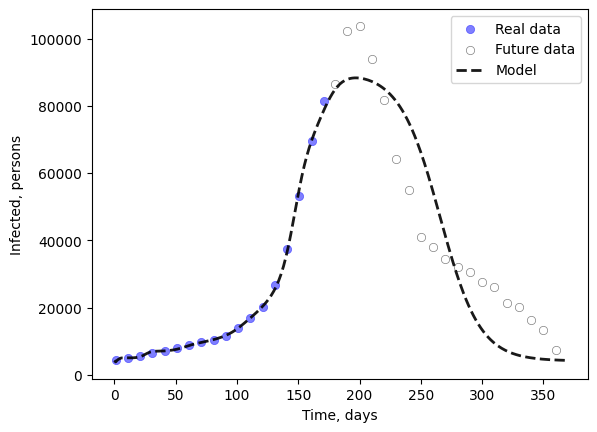

In [30]:
plt.scatter(timesteps[:x+1][1::10], infected[:x+1][1::10],
            c='blue', alpha=0.5, lw=0.5, label='Real data')
plt.scatter(timesteps[x:][::10], infected[x:][::10], c='white',
            edgecolors='black', alpha=0.5, lw=0.5, label='Future data')
plt.plot(timesteps, I_pred.cpu().detach().numpy(
), 'black', alpha=0.9, lw=2, label='Model', linestyle='dashed')
plt.xlabel("Time, days")
plt.ylabel("Infected, persons")
plt.legend()
plt.show()